# Satellite Image Land-Use Classifier & Temporal Change Detector

## Notebook 01: Dataset Exploration & Verification

**Objective**
- Verify the EuroSAT dataset
- Explore class distribution
- Inspect image samples
- Validate image integrity
- Prepare the dataset for model training

---

In [1]:
import os
import sys

# Current working directory
print("Current Working Directory:", os.getcwd())

# Move to project root if notebook is inside notebooks/
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print("Project Root:", os.getcwd())

# Add project root to Python path
sys.path.append(os.getcwd())

Current Working Directory: C:\Users\Akshit\satellite-landuse-change-detector\notebooks
Project Root: C:\Users\Akshit\satellite-landuse-change-detector


In [2]:
from src.config import print_config
from src.data.dataset import EuroSATDataset

In [3]:
print_config()

Project Configuration
Project Root : C:\Users\Akshit\satellite-landuse-change-detector
EuroSAT Path : C:\Users\Akshit\satellite-landuse-change-detector\data\raw\EuroSAT\2750
UC Merced    : C:\Users\Akshit\satellite-landuse-change-detector\data\raw\uc_merced
Device        : cpu
Image Size    : 224
Batch Size    : 32


In [4]:
dataset = EuroSATDataset()

In [5]:
dataset.summary()

EuroSAT Dataset Summary
Dataset Path  : C:\Users\Akshit\satellite-landuse-change-detector\data\raw\EuroSAT\2750
Total Classes : 10
Total Images  : 27000

Images per Class

AnnualCrop                3000
Forest                    3000
HerbaceousVegetation      3000
Highway                   2500
Industrial                2500
Pasture                   2000
PermanentCrop             2500
Residential               3000
River                     2500
SeaLake                   3000


In [6]:
dataset.verify_images()

Dataset Integrity Report
Total Images      : 27000
Corrupted Images  : 0

Image Resolutions
(64, 64) : 27000


## Sample Images from Each Land-Use Class

In [7]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

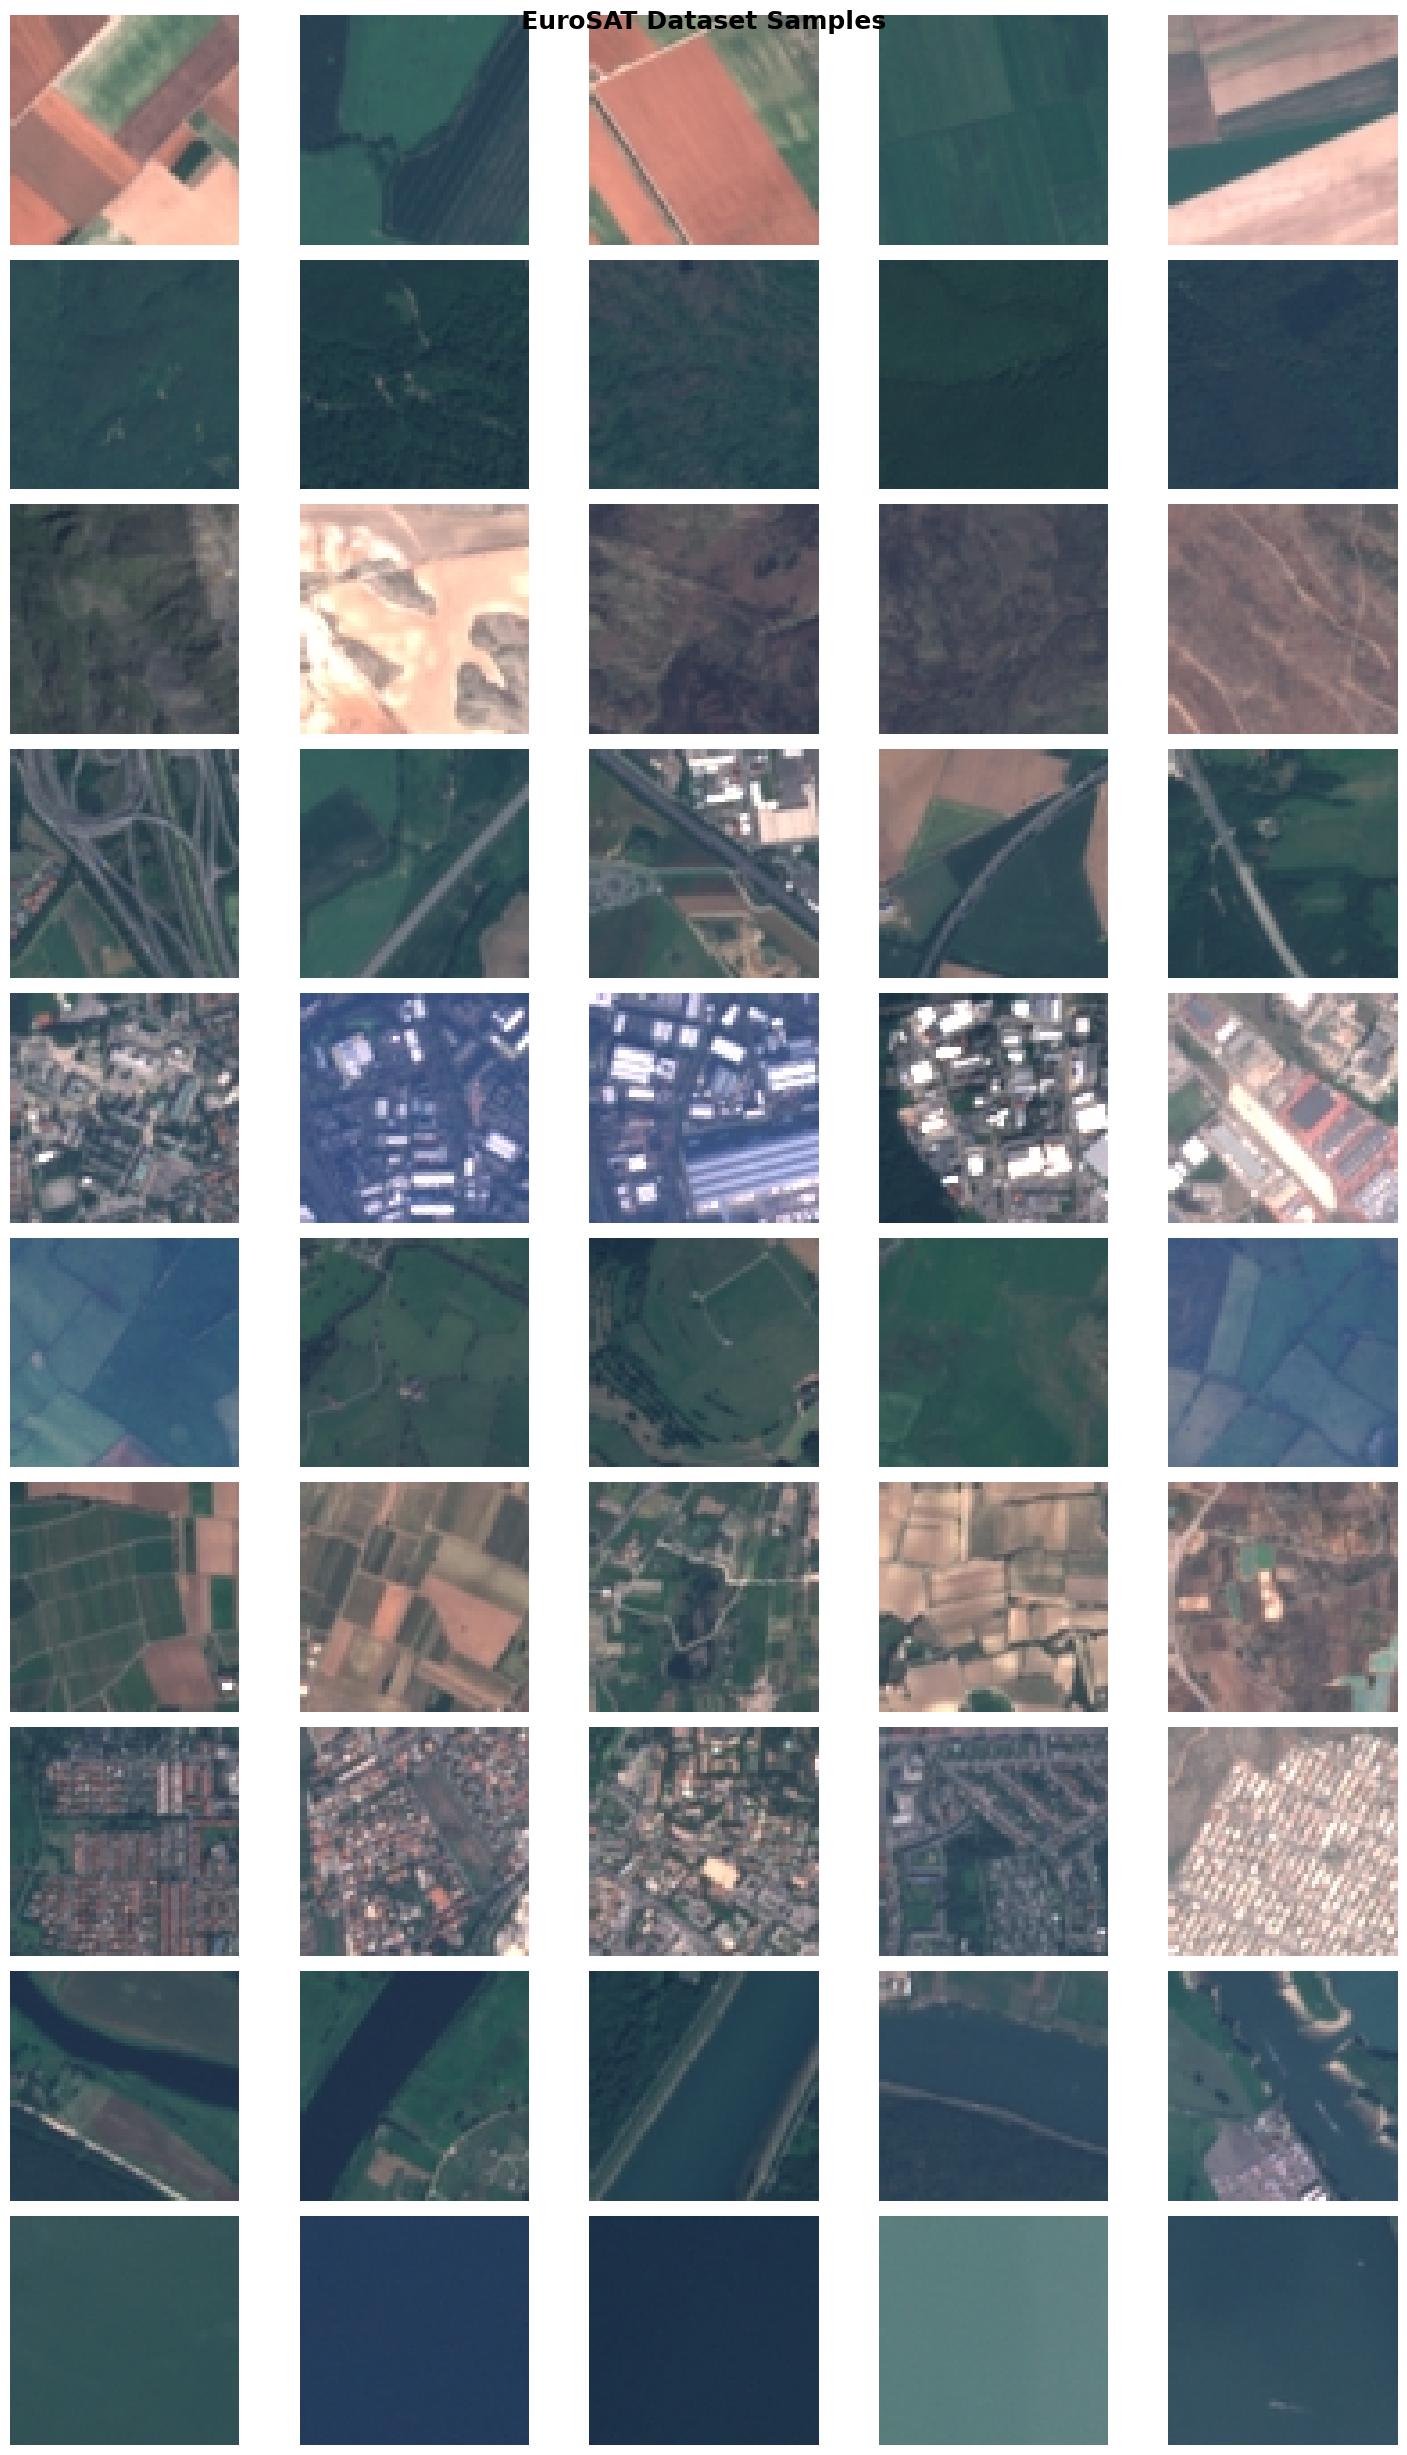

In [11]:
class_names = dataset.classes

fig, axes = plt.subplots(len(class_names), 5, figsize=(15, 25))

for row, class_name in enumerate(class_names):

    image_paths = list((dataset.dataset_path / class_name).glob("*"))

    sample_images = random.sample(image_paths, 5)

    for col, image_path in enumerate(sample_images):

        img = Image.open(image_path)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                class_name,
                fontsize=12,
                rotation=0,
                labelpad=60,
                va="center"
            )

plt.suptitle(
    "EuroSAT Dataset Samples",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Class Distribution

,Class,Images
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


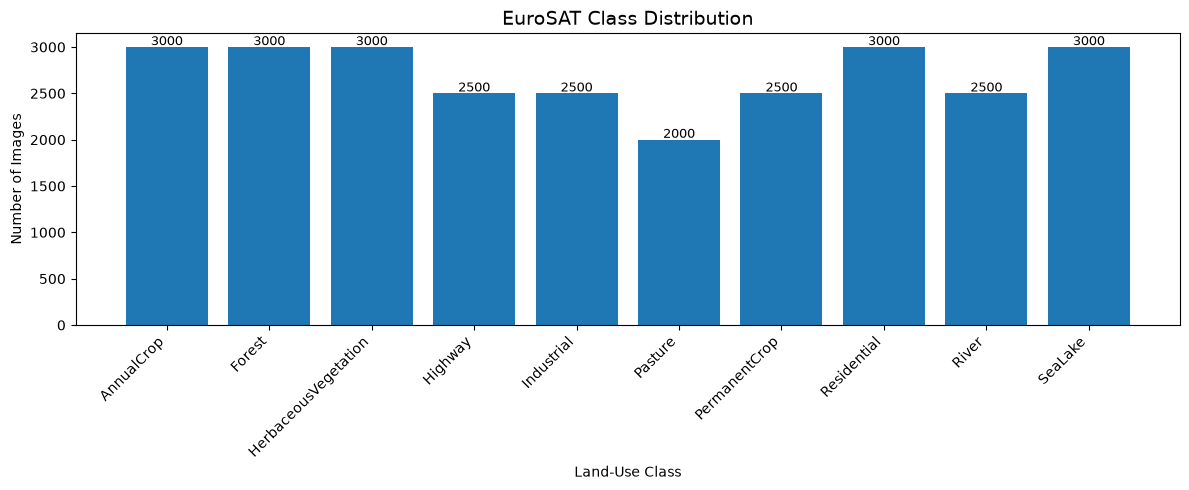

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

counts = dataset.count_images()

df = (
    pd.DataFrame(
        counts.items(),
        columns=["Class", "Images"]
    )
    .sort_values("Class")
)

display(df)

plt.figure(figsize=(12, 5))

bars = plt.bar(df["Class"], df["Images"])

plt.title("EuroSAT Class Distribution", fontsize=14)
plt.xlabel("Land-Use Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        str(height),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURES_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [16]:
print(FIGURES_DIR)
print(FIGURES_DIR.exists())
print(list(FIGURES_DIR.iterdir()))

C:\Users\Akshit\satellite-landuse-change-detector\outputs\figures
True
[WindowsPath('C:/Users/Akshit/satellite-landuse-change-detector/outputs/figures/class_distribution.png')]


## Image Resolution Analysis

In [17]:
from collections import Counter
from PIL import Image

resolution_counter = Counter()

for class_name in dataset.classes:

    class_path = dataset.dataset_path / class_name

    for image_path in class_path.glob("*"):

        try:
            with Image.open(image_path) as img:
                resolution_counter[img.size] += 1
        except:
            pass

resolution_df = pd.DataFrame(
    resolution_counter.items(),
    columns=["Resolution", "Count"]
)

display(resolution_df)

,Resolution,Count
0,"(64, 64)",27000


In [20]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

resolution_df.to_csv(
    METRICS_DIR / "image_resolution.csv",
    index=False
)

print(f"Saved successfully to:\n{METRICS_DIR / 'image_resolution.csv'}")

Saved successfully to:
C:\Users\Akshit\satellite-landuse-change-detector\outputs\metrics\image_resolution.csv


# Dataset Exploration Summary

### Key Findings

- Successfully verified the EuroSAT dataset containing 27,000 RGB satellite images.
- Dataset consists of 10 land-use categories.
- No corrupted images were detected.
- All images have a uniform resolution of 64 × 64 pixels.
- The dataset shows moderate class imbalance (2,000–3,000 images per class).
- The dataset is suitable for transfer learning using ResNet-18.